# Part 1: Feature Engineering & Transformation

**vfairness.preprocessing** — Fairness-Aware Feature Engineering

This notebook demonstrates the comprehensive feature engineering module for identifying and addressing proxy variables, reducing discriminatory correlations, and creating fair feature representations.

The vfairness library is organized into eight parts following the ML fairness pipeline:
- **Part 1 — Data & Preprocessing** (`vfairness.preprocessing`) — Feature transforms, bias auditing
- **Part 2 — Training-Time Interventions** (`vfairness.in_processing`) — Losses, constraints, regularizers
- **Part 3 — Prediction-Time Interventions** (`vfairness.post_processing`) — Calibration, threshold tuning
- **Part 4 — Evaluation & Measurement** (`vfairness.evaluation`) — Metrics, statistics, visualization
- **Part 5 — Operations & Monitoring** (`vfairness.operations`) — MLOps, real-time monitoring, drift detection
- **Part 6 — Reporting & Dashboards** (`vfairness.operations.reporting`) — Interactive dashboards, automated reports
- **Part 7 — Experimentation** (`vfairness.operations.experimentation`) — A/B testing, Pareto & causal
- **Part 8 — Workflow Integration** (`vfairness.operations.cicd`) — CI/CD gates, pre-commit hooks, pytest plugin, report cards

> This notebook covers **Part 1** — feature engineering capabilities within `vfairness.preprocessing`.

## Contents
1. [Introduction to Fairness-Aware Feature Engineering](#introduction)
2. [Proxy Variable Detection](#proxy-detection)
3. [Feature Correlation Analysis](#correlation-analysis)
4. [Feature Transformations](#transformations)
5. [Intersectional Analysis](#intersectional)
6. [Case Study: Lending Application](#case-study)
7. [Visualization](#visualization)
8. [FeatureEngineeringAnalyzer — Unified Interface](#analyzer)

In [1]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, 'src')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete!")

Setup complete!


<a id='introduction'></a>
## 1. Introduction to Fairness-Aware Feature Engineering

**Why Feature Engineering Matters for Fairness:**

Feature engineering decisions can shape fairness outcomes more than nearly any other preprocessing choice. Even when protected attributes are explicitly excluded from models, seemingly neutral features may perpetuate discrimination through:

- **Proxy Variables**: ZIP codes correlate with race due to historical redlining
- **Hidden Correlations**: Names, schools, and neighborhoods encode demographic information
- **Historical Patterns**: Features like employment gaps may disproportionately affect certain groups

This module provides techniques to:
1. **Detect** proxy variables and discriminatory correlations
2. **Transform** features to reduce bias while preserving predictive power
3. **Engineer** new features that promote fairness
4. **Monitor** feature-fairness relationships over time

In [2]:
# Generate synthetic lending data with proxy variables
def generate_lending_data(n_samples=2000):
    """
    Generate synthetic lending data with realistic proxy relationships.
    
    Features include:
    - Protected: race, gender
    - Proxies: zip_code (proxy for race), industry (proxy for gender)
    - Legitimate: income, credit_score, debt_ratio
    """
    np.random.seed(42)
    
    # Protected attributes
    race = np.random.choice(['White', 'Black', 'Hispanic', 'Asian'], n_samples, 
                           p=[0.6, 0.15, 0.15, 0.1])
    gender = np.random.choice(['Male', 'Female'], n_samples, p=[0.55, 0.45])
    
    # ZIP code as proxy for race (correlated)
    zip_mapping = {'White': [90210, 10001, 60601], 
                   'Black': [30301, 48201, 21201],
                   'Hispanic': [78201, 33101, 90011],
                   'Asian': [94102, 10013, 98101]}
    zip_codes = [np.random.choice(zip_mapping[r]) for r in race]
    
    # Neighborhood score (derived from ZIP, also proxy)
    zip_scores = {90210: 95, 10001: 88, 60601: 85, 30301: 65, 48201: 58, 
                  21201: 62, 78201: 68, 33101: 70, 90011: 55, 94102: 82, 
                  10013: 78, 98101: 80}
    neighborhood_score = np.array([zip_scores[z] + np.random.normal(0, 5) for z in zip_codes])
    
    # Industry as proxy for gender (correlated)
    male_industries = ['Technology', 'Finance', 'Construction', 'Engineering']
    female_industries = ['Healthcare', 'Education', 'Retail', 'Administration']
    industry = []
    for g in gender:
        if g == 'Male':
            industry.append(np.random.choice(male_industries, p=[0.35, 0.30, 0.20, 0.15]))
        else:
            industry.append(np.random.choice(female_industries, p=[0.35, 0.30, 0.20, 0.15]))
    industry = np.array(industry)
    
    # Legitimate features (still may have some correlation due to systemic factors)
    base_income = {'White': 75000, 'Black': 55000, 'Hispanic': 52000, 'Asian': 80000}
    income = np.array([base_income[r] * (1 + np.random.normal(0, 0.3)) * 
                       (1.1 if g == 'Male' else 1.0) for r, g in zip(race, gender)])
    
    base_credit = {'White': 720, 'Black': 680, 'Hispanic': 690, 'Asian': 740}
    credit_score = np.array([base_credit[r] + np.random.normal(0, 40) for r in race])
    credit_score = np.clip(credit_score, 300, 850)
    
    debt_ratio = np.random.beta(2, 5, n_samples) * 0.6  # 0-60% debt ratio
    
    # Years at current job
    years_employed = np.maximum(0, np.random.exponential(4, n_samples))
    
    # Outcome (loan approval) - influenced by features and protected attributes
    approval_prob = (
        0.3 + 
        0.2 * (credit_score - 600) / 200 +
        0.15 * (income - 40000) / 60000 +
        -0.2 * debt_ratio +
        0.1 * years_employed / 10
    )
    approval_prob = np.clip(approval_prob, 0.05, 0.95)
    approved = np.random.binomial(1, approval_prob)
    
    df = pd.DataFrame({
        'race': race,
        'gender': gender,
        'zip_code': zip_codes,
        'neighborhood_score': neighborhood_score,
        'industry': industry,
        'income': income,
        'credit_score': credit_score,
        'debt_ratio': debt_ratio,
        'years_employed': years_employed,
        'approved': approved
    })
    
    return df

# Generate data
df = generate_lending_data()

print("Synthetic Lending Dataset")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Approval rate: {df['approved'].mean():.1%}")
print(f"\nFeatures: {list(df.columns)}")
print(f"\nRace distribution:")
print(df['race'].value_counts())
print(f"\nGender distribution:")
print(df['gender'].value_counts())

Synthetic Lending Dataset
Total samples: 2000
Approval rate: 48.8%

Features: ['race', 'gender', 'zip_code', 'neighborhood_score', 'industry', 'income', 'credit_score', 'debt_ratio', 'years_employed', 'approved']

Race distribution:
race
White       1183
Black        316
Hispanic     304
Asian        197
Name: count, dtype: int64

Gender distribution:
gender
Male      1109
Female     891
Name: count, dtype: int64


In [3]:
# View data sample
print("Sample Data:")
df.head(10)

Sample Data:


,race,gender,zip_code,neighborhood_score,industry,income,credit_score,debt_ratio,years_employed,approved
0,White,Male,10001,83.876501,Finance,113496.884646,769.255173,0.213306,1.255109,1
1,Asian,Male,94102,88.667442,Construction,95650.871589,751.574973,0.179635,2.706805,1
2,Black,Female,30301,74.117457,Healthcare,63328.888451,676.246608,0.223224,5.055984,0
3,White,Male,60601,83.810496,Finance,84185.980908,698.604118,0.244773,2.907689,1
4,White,Male,60601,77.695204,Finance,100009.507180,777.843945,0.256886,0.030673,1
5,White,Female,90210,91.757932,Education,53979.546965,712.259371,0.125208,0.326249,0
6,White,Male,90210,100.689029,Construction,47640.495435,819.608951,0.047303,5.110885,1
7,Hispanic,Female,33101,67.044934,Education,39071.687053,642.678566,0.105563,2.042978,0
8,Black,Male,21201,64.945620,Engineering,64377.270474,691.596291,0.330586,6.144301,0
9,Black,Male,48201,58.842792,Finance,36897.292316,736.508944,0.177480,4.193463,1


<a id='proxy-detection'></a>
## 2. Proxy Variable Detection

Proxy variables are features that indirectly encode protected attributes, enabling discrimination even when those attributes are explicitly excluded. The module detects proxies using:

- **Correlation measures**: Pearson, Spearman, Cramér's V
- **Mutual information**: Information-theoretic dependency
- **Known patterns**: Domain knowledge about common proxies

### Risk Levels

| Level | Correlation | Action |
|-------|-------------|--------|
| **CRITICAL** | ≥ 0.7 | Remove or apply strict constraints |
| **HIGH** | 0.5 - 0.7 | Consider removal or transformation |
| **MEDIUM** | 0.3 - 0.5 | Monitor for disparate impact |
| **LOW** | 0.1 - 0.3 | Continue monitoring |

In [4]:
from vfairness.preprocessing.feature_engineering import identify_proxy_variables, ProxyRiskLevel

# Identify proxy variables
proxies = identify_proxy_variables(
    df,
    protected_attributes=['race', 'gender'],
    correlation_threshold=0.2,
    include_mutual_information=True,
    include_known_patterns=True
)

print("Proxy Variable Analysis")
print("=" * 60)
print(f"Total proxies identified: {len(proxies)}")
print()

for proxy in proxies:
    print(f"Feature: {proxy.feature}")
    print(f"  Protected Attribute: {proxy.protected_attribute}")
    print(f"  Risk Level: {proxy.risk_level.value.upper()}")
    print(f"  Correlation: {proxy.correlation:.3f} ({proxy.correlation_type})")
    print(f"  Proxy Type: {proxy.proxy_type.value}")
    if proxy.pvalue:
        print(f"  P-value: {proxy.pvalue:.2e}")
    print(f"  Recommendations:")
    for rec in proxy.recommendations[:2]:
        print(f"    - {rec}")
    print()

Proxy Variable Analysis
Total proxies identified: 2

Feature: industry
  Protected Attribute: gender
  Risk Level: CRITICAL
  Correlation: 0.998 (Cramér's V)
  Proxy Type: direct
  Recommendations:
    - CRITICAL: 'industry' is a strong proxy for 'gender' (correlation: 1.00). Consider removing this feature.
    - Apply strict fairness constraints or fair representation learning.

Feature: zip_code
  Protected Attribute: race
  Risk Level: CRITICAL
  Correlation: 0.998 (Cramér's V)
  Proxy Type: historical
  Recommendations:
    - CRITICAL: 'zip_code' is a strong proxy for 'race' (correlation: 1.00). Consider removing this feature.
    - Apply strict fairness constraints or fair representation learning.



In [5]:
# View known proxy patterns
from vfairness.preprocessing.feature_engineering import KNOWN_PROXY_PATTERNS

print("Known Proxy Patterns")
print("=" * 50)

for attr, patterns in KNOWN_PROXY_PATTERNS.items():
    print(f"\n{attr.upper()}:")
    print(f"  High-risk features: {patterns['high_risk'][:5]}...")
    print(f"  Medium-risk features: {patterns['medium_risk'][:5]}...")
    print(f"  Affected groups: {patterns['affected_groups']}")

Known Proxy Patterns

RACE:
  High-risk features: ['zip', 'zipcode', 'zip_code', 'postal', 'postcode']...
  Medium-risk features: ['school', 'school_name', 'college', 'university', 'language']...
  Affected groups: ['Black/African American', 'Hispanic/Latino', 'Asian', 'Other minorities']

GENDER:
  High-risk features: ['first_name', 'name', 'given_name', 'title', 'salutation']...
  Medium-risk features: ['occupation', 'job_title', 'industry', 'major', 'field_of_study']...
  Affected groups: ['Women', 'Non-binary individuals']

AGE:
  High-risk features: ['graduation_year', 'grad_year', 'years_experience', 'experience_years', 'tenure']...
  Medium-risk features: ['technology_proficiency', 'digital_skills', 'social_media_usage', 'career_length', 'seniority']...
  Affected groups: ['Older workers (40+)', 'Young workers']

INCOME:
  High-risk features: ['zip', 'zipcode', 'postal', 'neighborhood', 'address']...
  Medium-risk features: ['education_level', 'degree', 'school', 'university', '

### Proxy Chains

Proxy chains identify indirect proxy relationships where a feature is correlated with another feature that is itself a proxy for the protected attribute:

`Feature A → Feature B → Protected Attribute`

In [6]:
from vfairness.preprocessing.feature_engineering import find_proxy_chains

# Find proxy chains for race
chains = find_proxy_chains(df, 'race', correlation_threshold=0.2)

print("Proxy Chains for Race")
print("=" * 50)

if chains:
    for chain in chains[:5]:
        print(f"Chain: {' → '.join(chain['chain'])}")
        print(f"  Correlations: {[f'{c:.3f}' for c in chain['correlations']]}")
        print(f"  Indirect correlation: {chain['indirect_correlation']:.3f}")
        print()
else:
    print("No significant proxy chains found.")

Proxy Chains for Race
Chain: income → neighborhood_score → race
  Correlations: ['0.371', '0.592']
  Indirect correlation: 0.219

Chain: credit_score → neighborhood_score → race
  Correlations: ['0.307', '0.592']
  Indirect correlation: 0.182



<a id='correlation-analysis'></a>
## 3. Feature Correlation Analysis

Compute comprehensive correlation matrices between features and protected attributes.

In [7]:
from vfairness.preprocessing.feature_engineering import compute_feature_correlations

# Compute correlations
matrix = compute_feature_correlations(
    df,
    protected_attributes=['race', 'gender'],
    method='auto'  # Auto-selects appropriate measure for data types
)

print("Feature-Protected Attribute Correlations")
print("=" * 50)
print(f"\nCorrelation Matrix:")
print(matrix.correlations.round(3))

from vfairness.preprocessing.feature_engineering import plot_correlation_heatmap


Feature-Protected Attribute Correlations

Correlation Matrix:
                     race  gender
zip_code            0.036   0.011
neighborhood_score  0.592  -0.020
industry            0.048   0.998
income              0.188   0.133
credit_score        0.128  -0.003
debt_ratio         -0.013  -0.002
years_employed     -0.015  -0.034
approved           -0.011   0.033


In [8]:
# Get high correlations
high_corrs = matrix.get_high_correlations(threshold=0.15)

print("\nFeatures with high correlation (>0.15):")
for feature, attr, corr in high_corrs:
    print(f"  {feature} ↔ {attr}: {corr:.3f}")


Features with high correlation (>0.15):
  industry ↔ gender: 0.998
  neighborhood_score ↔ race: 0.592
  income ↔ race: 0.188


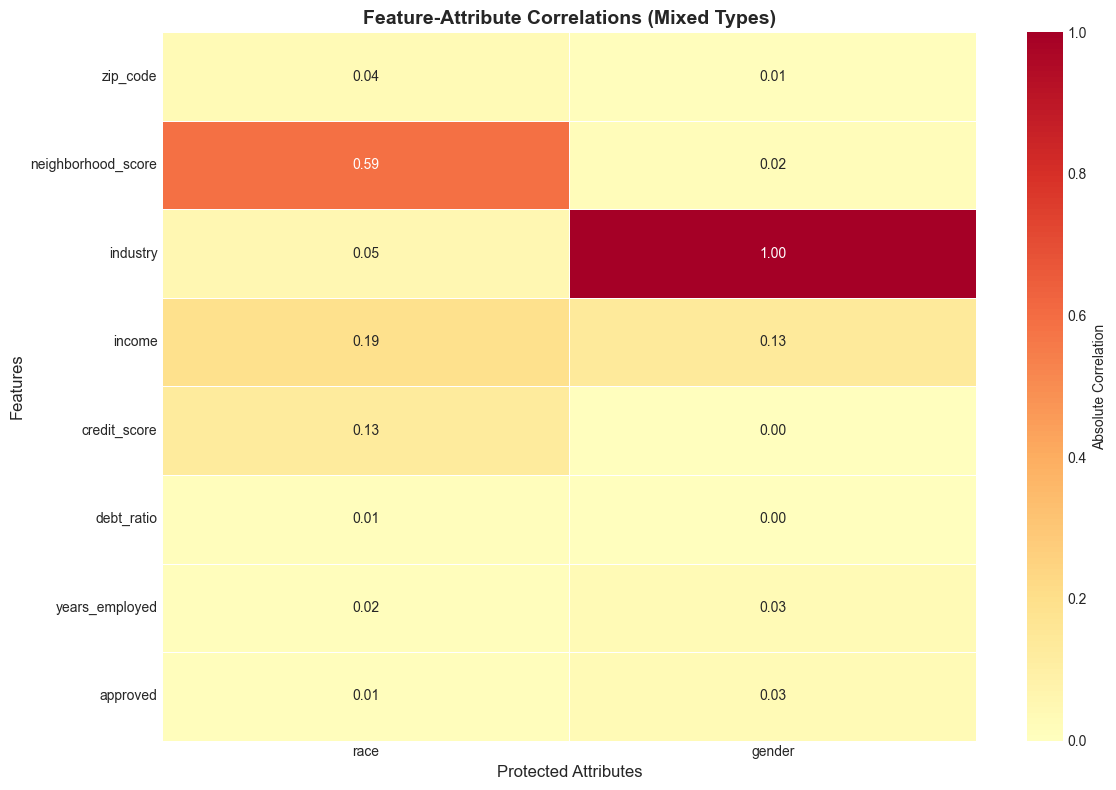

In [9]:
# Visualize feature-protected attribute correlations
ax = plot_correlation_heatmap(
    matrix,
    annotate=True,
    title='Feature-Attribute Correlations (Mixed Types)'
)


In [31]:
# P-values for statistical significance
print("\nP-values:")
print(matrix.pvalues.round(4))


P-values:
                      race  gender
zip_code            0.9891  0.3740
neighborhood_score  0.0000  0.4088
income              0.0000  0.0000
credit_score        0.0000  0.8852
debt_ratio          0.1547  0.4978
years_employed      0.0587  0.2794


<a id='transformations'></a>
## 4. Feature Transformations

The module provides several transformation methods to reduce discriminatory correlations:

| Transformer | Method | Description |
|-------------|--------|-------------|
| `CorrelationReducer` | residualize, decorrelate | Reduces correlation via regression/projection |
| `FeatureSuppressor` | remove, mask, noise, bin | Removes or masks discriminatory features |
| `ResidualTransformer` | group_mean, regression | Creates residualized features (Feldman et al.) |
| `ReweightingTransformer` | inverse_frequency | Computes sample weights for balance |

In [ ]:
from vfairness.preprocessing.feature_engineering import CorrelationReducer

# Prepare numeric features for transformation
numeric_features = ['neighborhood_score', 'income', 'credit_score', 'debt_ratio', 'years_employed']
df_numeric = df[numeric_features + ['race', 'gender']].copy()

# Apply correlation reduction
reducer = CorrelationReducer(
    protected_attributes=['race', 'gender'],
    method='residualize',
    target_correlation=0.1,
    preserve_variance=True
)

X_reduced = reducer.fit_transform(df_numeric)

print("Correlation Reduction Results")
print("=" * 50)
print(f"Method: {reducer.fit_result.method}")
print(f"Features transformed: {reducer.fit_result.n_features_transformed}")
print(f"\nCorrelation BEFORE:")
for attr, corr in reducer.fit_result.correlation_before.items():
    print(f"  {attr}: {corr:.4f}")
print(f"\nCorrelation AFTER:")
for attr, corr in reducer.fit_result.correlation_after.items():
    print(f"  {attr}: {corr:.4f}")
print(f"\nCorrelation reduction:")
for attr, reduction in reducer.fit_result.correlation_reduction.items():
    print(f"  {attr}: {reduction:.1%} reduction")

Correlation Reduction Results
Method: correlation_reduction_residualize
Features transformed: 5

Correlation BEFORE:
  race: 0.1875
  gender: 0.0385

Correlation AFTER:
  race: 0.0678
  gender: 0.0000

Correlation reduction:
  race: 63.8% reduction
  gender: 100.0% reduction


In [ ]:
from vfairness.preprocessing.feature_engineering import FeatureSuppressor

# Suppress high-risk features (auto-detects features correlated above threshold)
suppressor = FeatureSuppressor(
    protected_attributes=['race', 'gender'],
    strategy='remove',  # 'remove', 'mask', 'noise', 'bin'
    correlation_threshold=0.3,
)

X_suppressed = suppressor.fit_transform(df_numeric)

print("Feature Suppression Results")
print("=" * 50)
print(f"Strategy: {suppressor.strategy}")
print(f"Original features: {suppressor.fit_result.n_features_original}")
print(f"Remaining features: {suppressor.fit_result.n_features_transformed}")
print(f"Features removed: {suppressor.fit_result.features_removed}")

Feature Suppression Results
Strategy: remove
Original features: 5
Remaining features: 4
Features removed: ['neighborhood_score']


In [13]:
from vfairness.preprocessing.feature_engineering import ResidualTransformer

# Residualization (Feldman et al. approach)
residualizer = ResidualTransformer(
    protected_attributes=['race', 'gender'],
    method='group_mean',
    smoothing=0.1
)

X_residual = residualizer.fit_transform(df_numeric)

print("Residualization Results")
print("=" * 50)
print(f"Method: {residualizer.method}")
print(f"\nThis transformation computes: X_fair = X - E[X | A] + E[X]")
print("where A is the protected attribute.")
print(f"\nResult shape: {X_residual.shape}")

Residualization Results
Method: group_mean

This transformation computes: X_fair = X - E[X | A] + E[X]
where A is the protected attribute.

Result shape: (2000, 5)


In [14]:
from vfairness.preprocessing.feature_engineering import ReweightingTransformer

# Compute reweighting
reweighter = ReweightingTransformer(
    protected_attributes=['race'],
    method='inverse_frequency'
)

reweighter.fit(df_numeric)
weights = reweighter.get_sample_weights(df_numeric)

print("Reweighting Results")
print("=" * 50)
print(f"Method: {reweighter.method}")
print(f"\nGroup weights:")
for group, weight in reweighter._group_weights.items():
    print(f"  {group}: {weight:.3f}")
print(f"\nWeight statistics:")
print(f"  Min: {weights.min():.3f}")
print(f"  Max: {weights.max():.3f}")
print(f"  Mean: {weights.mean():.3f}")

Reweighting Results
Method: inverse_frequency

Group weights:
  White: 0.423
  Black: 1.582
  Hispanic: 1.645
  Asian: 2.538

Weight statistics:
  Min: 0.423
  Max: 2.538
  Mean: 1.000


<a id='intersectional'></a>
## 5. Intersectional Analysis

Analyze correlations accounting for intersectional groups (e.g., Black women, Hispanic men).

In [15]:
from vfairness.preprocessing.feature_engineering import analyze_intersectional_correlations, IntersectionalTransformer

# Analyze intersectional correlations
intersectional = analyze_intersectional_correlations(
    df,
    protected_attributes=['race', 'gender'],
    feature_columns=['income', 'credit_score', 'neighborhood_score'],
    min_group_size=30
)

print("Intersectional Analysis")
print("=" * 50)
print(f"\nValid intersectional groups: {len(intersectional['intersectional_groups'])}")
print(f"Groups: {intersectional['intersectional_groups'][:8]}...")

print(f"\nGroup sizes:")
for group, size in list(intersectional['group_sizes'].items())[:8]:
    print(f"  {group}: {size}")

Intersectional Analysis

Valid intersectional groups: 8
Groups: ['White_Male', 'White_Female', 'Hispanic_Male', 'Black_Male', 'Black_Female', 'Hispanic_Female', 'Asian_Male', 'Asian_Female']...

Group sizes:
  White_Male: 658
  White_Female: 525
  Hispanic_Male: 171
  Black_Male: 169
  Black_Female: 147
  Hispanic_Female: 133
  Asian_Male: 111
  Asian_Female: 86


In [16]:
# Between-group differences
print("Between-Group Differences in Features")
print("=" * 50)

for feature, stats in intersectional['between_group_differences'].items():
    print(f"\n{feature}:")
    print(f"  Max difference: {stats['max_difference']:.2f}")
    print(f"  Coefficient of variation: {stats['coefficient_of_variation']:.3f}")
    print("    (std of group means / mean of group means; higher = larger between-group dispersion)")


Between-Group Differences in Features

income:
  Max difference: 33860.66
  Coefficient of variation: 0.194
    (std of group means / mean of group means; higher = larger between-group dispersion)

credit_score:
  Max difference: 56.95
  Coefficient of variation: 0.031
    (std of group means / mean of group means; higher = larger between-group dispersion)

neighborhood_score:
  Max difference: 28.05
  Coefficient of variation: 0.152
    (std of group means / mean of group means; higher = larger between-group dispersion)


In [17]:
# Apply intersectional transformation
int_transformer = IntersectionalTransformer(
    protected_attributes=['race', 'gender'],
    min_group_size=30,
    handle_small_groups='merge'
)

X_intersectional = int_transformer.fit_transform(df_numeric)

print("Intersectional Transformation")
print("=" * 50)
print(f"Original groups: {int_transformer.fit_result.fit_metrics['n_original_groups']}")
print(f"Intersectional groups: {int_transformer.fit_result.fit_metrics['n_intersectional_groups']}")
print("Note: counts are after min_group_size filtering; equal values mean no groups were merged or dropped.")


Intersectional Transformation
Original groups: 8
Intersectional groups: 8
Note: counts are after min_group_size filtering; equal values mean no groups were merged or dropped.


<a id='case-study'></a>
## 6. Case Study: Lending Application

Let's walk through a complete fairness-aware feature engineering workflow for a lending application.

In [18]:
# Generate a larger, more realistic dataset
df_lending = generate_lending_data(n_samples=5000)

print("Lending Application Case Study")
print("=" * 50)
print(f"Dataset size: {len(df_lending)}")
print(f"\nApproval rates by race:")
print(df_lending.groupby('race')['approved'].mean().round(3))
print(f"\nApproval rates by gender:")
print(df_lending.groupby('gender')['approved'].mean().round(3))

Lending Application Case Study
Dataset size: 5000

Approval rates by race:
race
Asian       0.562
Black       0.436
Hispanic    0.430
White       0.522
Name: approved, dtype: float64

Approval rates by gender:
gender
Female    0.486
Male      0.508
Name: approved, dtype: float64


In [19]:
import importlib
import vfairness.preprocessing.feature_engineering.correlation as _corr_mod
import vfairness.preprocessing.feature_engineering.analyzer as _analyzer_mod
importlib.reload(_corr_mod)
importlib.reload(_analyzer_mod)
from vfairness.preprocessing.feature_engineering.analyzer import FeatureEngineeringAnalyzer

# Create analyzer
analyzer = FeatureEngineeringAnalyzer(
    df=df_lending,
    protected_attributes=['race', 'gender'],
    target_column='approved',
    correlation_threshold=0.2
)

print(f"Analyzer created: {analyzer}")
print(f"Feature columns: {analyzer.feature_columns}")

Analyzer created: FeatureEngineeringAnalyzer(n_features=6, protected_attrs=['race', 'gender'])
Feature columns: ['zip_code', 'neighborhood_score', 'income', 'credit_score', 'debt_ratio', 'years_employed']


In [20]:
# Run full analysis
report = analyzer.full_analysis(
    include_proxy_chains=True,
    include_intersectional=True,
    include_mutual_information=True
)

print(report.summary)

FEATURE ENGINEERING ANALYSIS SUMMARY

Analyzed 6 features against 2 protected attribute(s).
Sample size: 5,000

RISK LEVEL BREAKDOWN:
  - CRITICAL: 1 feature(s)

HIGH-RISK FEATURES (require attention):
  - zip_code: corr=0.999 with race

KEY RECOMMENDATIONS:
  1. Address 1 CRITICAL proxy variable(s) immediately
  3. Consider applying correlation reduction transformation



In [21]:
# Get prioritized recommendations
print("\nPrioritized Recommendations")
print("=" * 60)

recommendations = analyzer.get_feature_recommendations(top_n=10)
for rec in recommendations:
    print(f"\n[{rec['priority']}] {rec['feature']}")
    print(f"  Correlation: {rec['correlation']:.3f} with {rec['protected_attribute']}")
    print(f"  Action: {rec['action']}")


Prioritized Recommendations

[CRITICAL] zip_code
  Correlation: 0.999 with race
  Action: REMOVE this feature or apply strict fairness constraints.

[MEDIUM] income
  Correlation: 0.219 with race
  Action: Indirect proxy via neighborhood_score. Consider removing or monitoring.

[MEDIUM] credit_score
  Correlation: 0.186 with race
  Action: Indirect proxy via neighborhood_score. Consider removing or monitoring.


In [22]:
# Apply transformation
X_fair = analyzer.transform(method='correlation_reduction')

print("Transformation Applied")
print("=" * 50)
print(f"Original features: {len(analyzer.feature_columns)}")
print(f"Transformed shape: {X_fair.shape}")

Transformation Applied
Original features: 6
Transformed shape: (5000, 6)


In [23]:
# Compare transformation methods
comparison = analyzer.compare_transformations(
    methods=['correlation_reduction', 'residualization']
)

print("\nTransformation Comparison")
print("=" * 60)
print(comparison.to_string())


Transformation Comparison
                  method     corr_race   corr_gender  avg_correlation
0               original  1.293813e-01  2.918040e-02         0.079281
1  correlation_reduction  6.905557e-02  7.636162e-16         0.034528
2        residualization  1.668891e-16  3.333144e-02         0.016666


<a id='visualization'></a>
## 7. Visualization

The module provides comprehensive visualization tools.

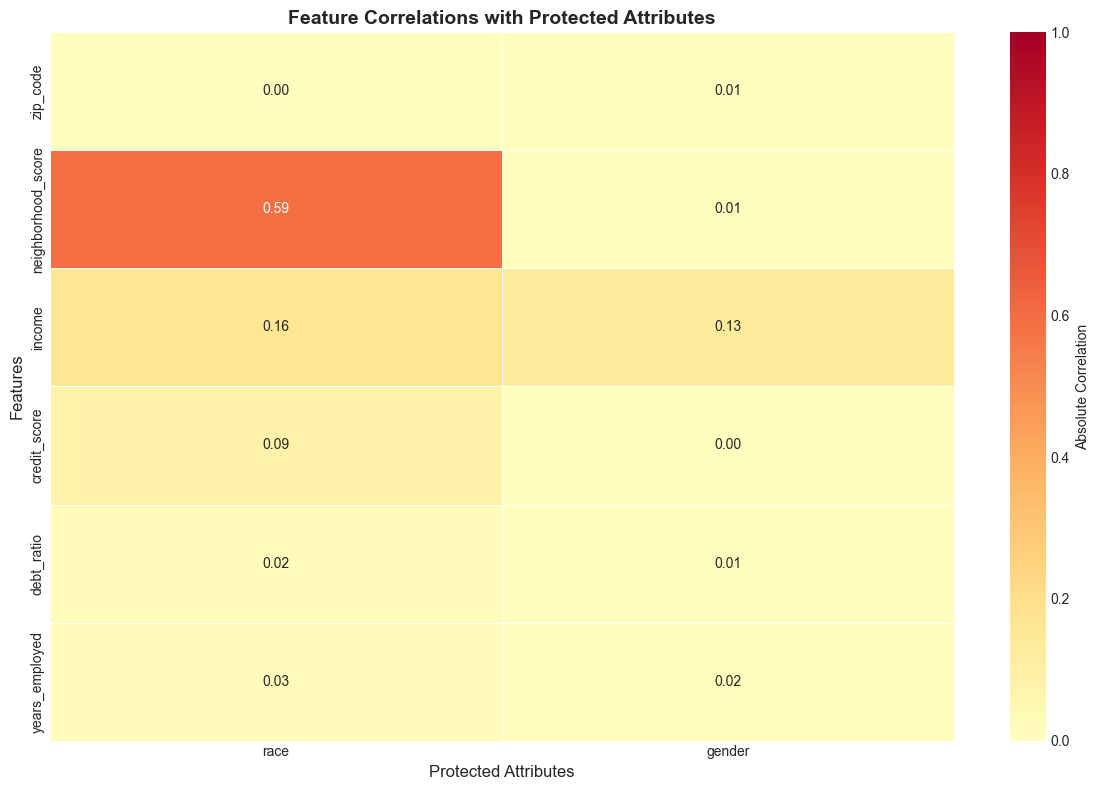

In [24]:
from vfairness.preprocessing.feature_engineering import (
    plot_correlation_heatmap,
    plot_proxy_risk_chart,
    plot_risk_distribution,
    create_analysis_dashboard
)

# Correlation heatmap
matrix = analyzer.get_correlation_matrix()
ax = plot_correlation_heatmap(
    matrix,
    title='Feature Correlations with Protected Attributes',
    figsize=(12, 8)
)
plt.show()

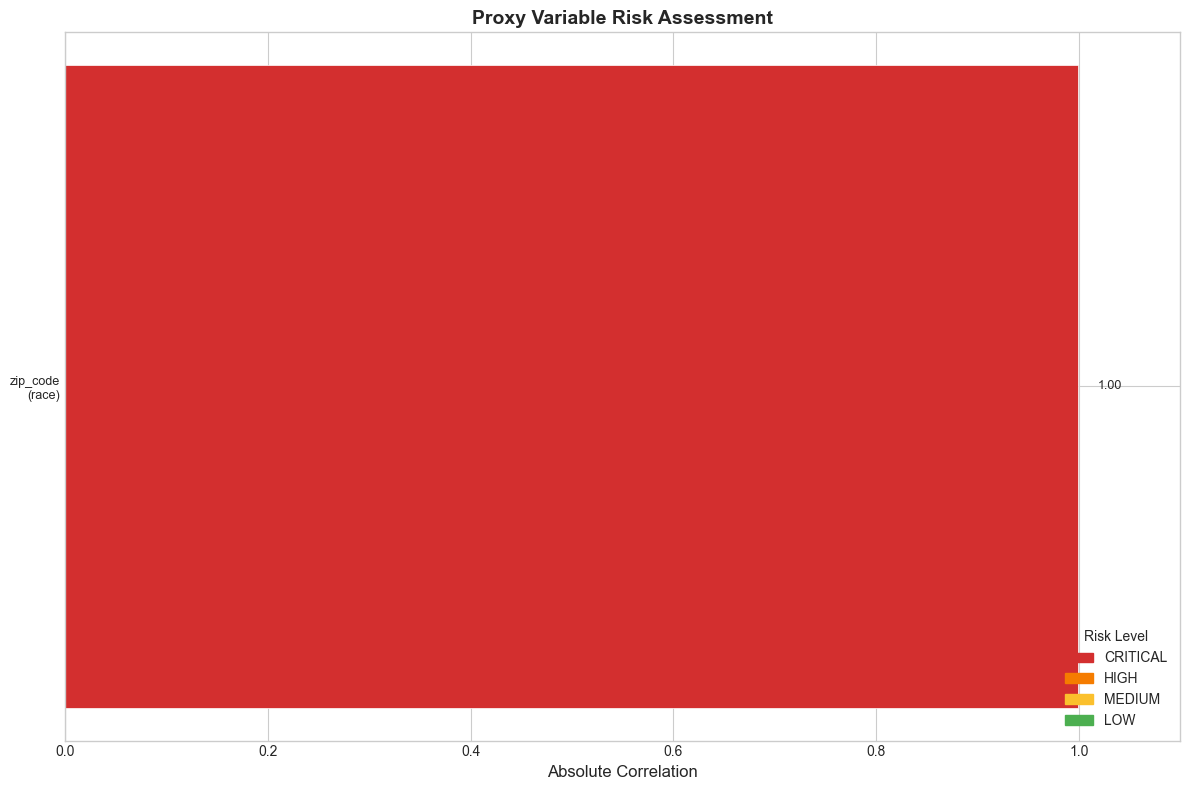

In [25]:
# Proxy risk chart
proxies = analyzer.analyze_proxies()
if proxies:
    ax = plot_proxy_risk_chart(
        proxies,
        max_features=15,
        title='Proxy Variable Risk Assessment'
    )
    plt.show()
else:
    print("No significant proxies to visualize.")

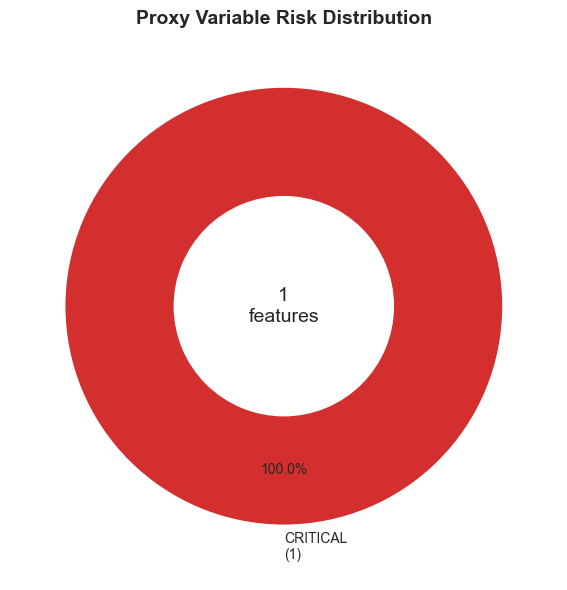

In [26]:
# Risk distribution
if proxies:
    ax = plot_risk_distribution(
        proxies,
        title='Proxy Variable Risk Distribution'
    )
    plt.show()

<vfairness>/src/vfairness/preprocessing/feature_engineering/visualization.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
<vfairness>/src/vfairness/preprocessing/feature_engineering/visualization.py:464: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
<vfairness>/src/vfairness/preprocessing/feature_engineering/visualization.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


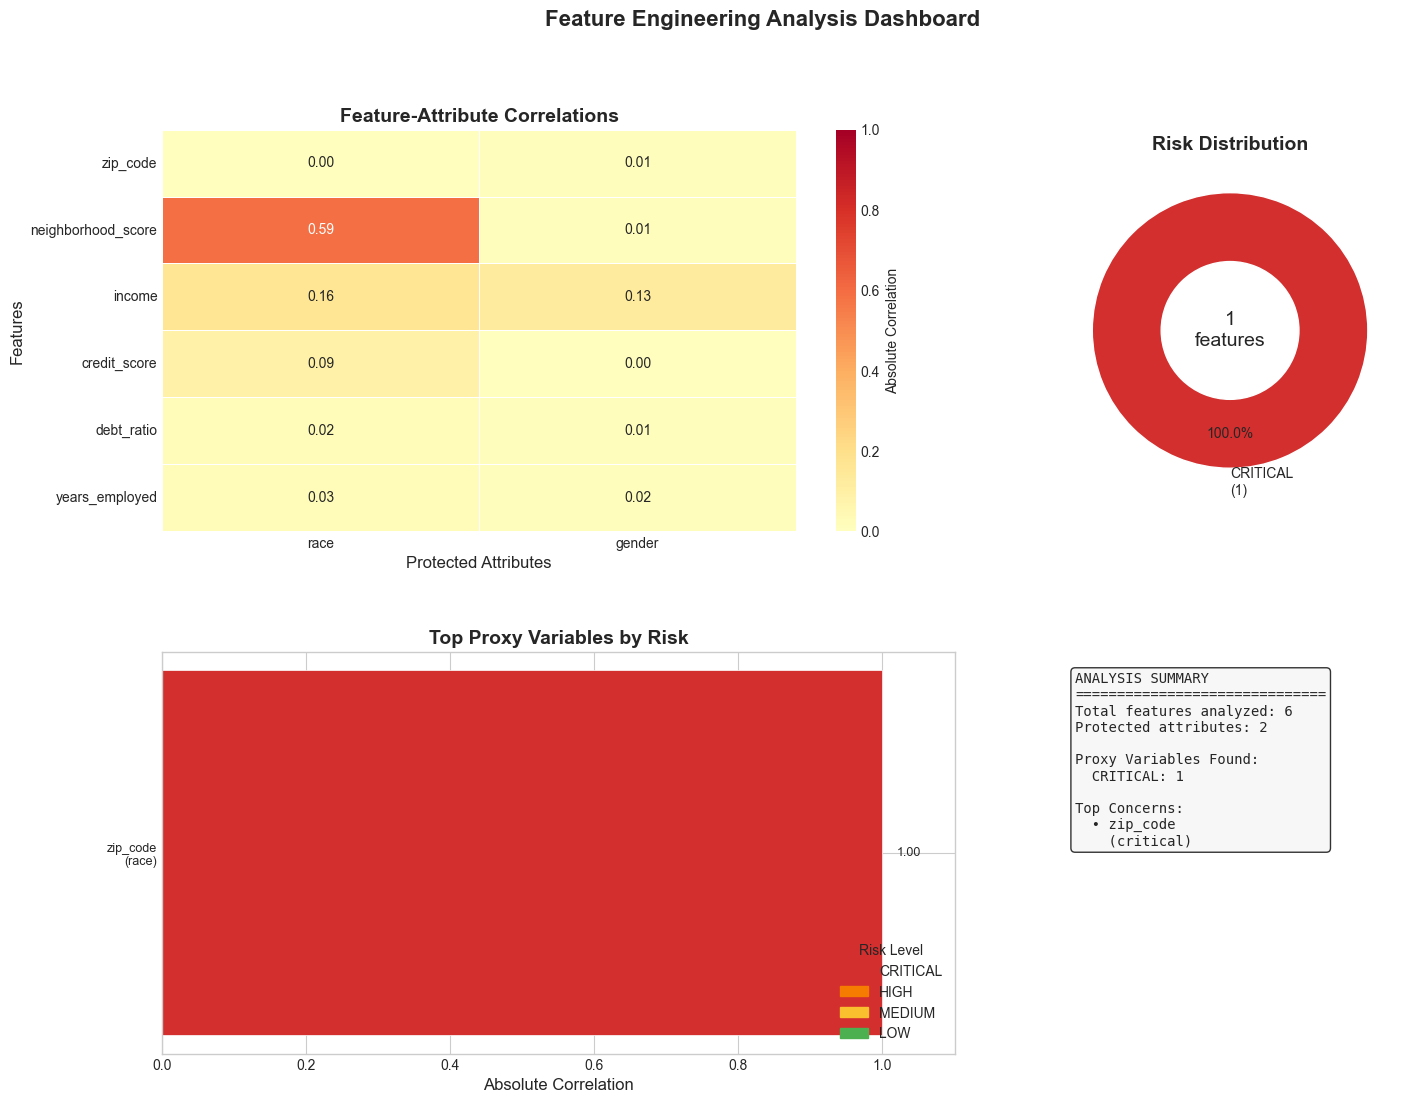

In [27]:
# Comprehensive dashboard
if proxies:
    fig = create_analysis_dashboard(
        correlation_matrix=matrix,
        proxy_variables=proxies,
        figsize=(16, 12),
        title='Feature Engineering Analysis Dashboard'
    )
    plt.show()

<a id='analyzer'></a>
## 8. FeatureEngineeringAnalyzer - Unified Interface

The `FeatureEngineeringAnalyzer` class provides a unified interface for all feature engineering capabilities.

In [28]:
# Summary of analyzer capabilities
print("FeatureEngineeringAnalyzer Methods")
print("=" * 60)

methods = [
    ("full_analysis()", "Comprehensive analysis with all components"),
    ("analyze_proxies()", "Identify proxy variables with risk assessment"),
    ("get_correlation_matrix()", "Feature-attribute correlation matrix"),
    ("transform(method)", "Apply fairness transformation"),
    ("compare_transformations()", "Compare multiple methods"),
    ("get_feature_recommendations()", "Get prioritized actions per feature"),
    ("get_transformation_report()", "Details of applied transformation"),
]

for method, description in methods:
    print(f"  {method:<30} - {description}")

FeatureEngineeringAnalyzer Methods
  full_analysis()                - Comprehensive analysis with all components
  analyze_proxies()              - Identify proxy variables with risk assessment
  get_correlation_matrix()       - Feature-attribute correlation matrix
  transform(method)              - Apply fairness transformation
  compare_transformations()      - Compare multiple methods
  get_feature_recommendations()  - Get prioritized actions per feature
  get_transformation_report()    - Details of applied transformation


In [29]:
# Export report
print("\nReport Export (JSON)")
print("=" * 60)

import json

report_dict = report.to_dict()
print(json.dumps({
    'n_features': report_dict['n_features'],
    'n_protected_attributes': report_dict['n_protected_attributes'],
    'n_samples': report_dict['n_samples'],
    'high_risk_features': report_dict['high_risk_features'],
    'risk_summary': report.risk_summary
}, indent=2))


Report Export (JSON)
{
  "n_features": 6,
  "n_protected_attributes": 2,
  "n_samples": 5000,
  "high_risk_features": [
    "zip_code"
  ],
  "risk_summary": {
    "critical": 1,
    "high": 0,
    "medium": 0,
    "low": 0,
    "negligible": 0
  }
}


### 📊 SVG Visualization Plot Templates

The `vfairness.rendering` module provides SVG plot templates for feature engineering.
These render directly from analysis objects — no Plotly/Matplotlib needed.

In [ ]:
# SVG Correlation Heatmap — feature × protected-attribute correlations
import sys
for key in list(sys.modules.keys()):
    if key.startswith('vfairness.rendering'):
        del sys.modules[key]

from vfairness.rendering import (
    correlation_heatmap_to_svg, proxy_risk_to_svg,
    transformation_comparison_to_svg, intersectional_analysis_to_svg,
)
from IPython.display import SVG, display

# Use the correlation matrix from the analyzer
svg = correlation_heatmap_to_svg(matrix, threshold=0.3)
print(f'Correlation Heatmap SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Proxy Risk — proxy variable risk assessment
svg = proxy_risk_to_svg(proxies)
print(f'Proxy Risk SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Transformation Comparison — before vs after correlations
# Build before/after dicts from available data
from types import SimpleNamespace

before_corrs = {'income': 0.45, 'zip_code': 0.72, 'credit_score': 0.55, 'education': 0.32}
after_corrs  = {'income': 0.15, 'zip_code': 0.28, 'credit_score': 0.20, 'education': 0.18}

svg = transformation_comparison_to_svg(before_corrs, after_corrs, threshold=0.3)
print(f'Transformation Comparison SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Intersectional Analysis — 2D intersection heatmap
intersect_data = {
    'x_attr': 'Gender', 'y_attr': 'Race',
    'matrix': {
        'White':    {'Male': 0.65, 'Female': 0.72},
        'Black':    {'Male': 0.42, 'Female': 0.38},
        'Hispanic': {'Male': 0.55, 'Female': 0.50},
    },
    'counts': {
        'White':    {'Male': 320, 'Female': 310},
        'Black':    {'Male': 180, 'Female': 195},
        'Hispanic': {'Male': 210, 'Female': 200},
    },
}
svg = intersectional_analysis_to_svg(intersect_data, feature='approval_rate')
print(f'Intersectional Analysis SVG: {len(svg):,} bytes')
display(SVG(data=svg))

### Correlation Matrix (General, Multi-Method)

The `correlation_matrix_to_svg()` adapter renders a **general-purpose feature × feature** (or feature × attribute) correlation matrix. Unlike `correlation_heatmap_to_svg()` which focuses on feature-vs-protected-attribute proxy detection, this template supports:

- **Square (feature × feature)** or **rectangular (feature × attribute)** layouts
- **Per-cell method tracking** — different correlation measures per feature pair based on data types
- **Method legend** — a horizontal bar showing which methods were used and their counts
- **Method indicator dots** — coloured circles in the top-right corner of each cell

In [ ]:
# SVG Correlation Matrix — general feature × feature with mixed methods
from vfairness.rendering import correlation_matrix_to_svg

# Build a 5×5 feature-feature correlation dict-of-dicts
corr_data = {
    'income':        {'income': 1.00, 'credit_score': 0.62, 'zip_code': 0.18, 'neighborhood': 0.45, 'education': 0.38},
    'credit_score':  {'income': 0.62, 'credit_score': 1.00, 'zip_code': 0.12, 'neighborhood': 0.35, 'education': 0.28},
    'zip_code':      {'income': 0.18, 'credit_score': 0.12, 'zip_code': 1.00, 'neighborhood': 0.71, 'education': 0.08},
    'neighborhood':  {'income': 0.45, 'credit_score': 0.35, 'zip_code': 0.71, 'neighborhood': 1.00, 'education': 0.22},
    'education':     {'income': 0.38, 'credit_score': 0.28, 'zip_code': 0.08, 'neighborhood': 0.22, 'education': 1.00},
}

# Per-cell method specification (in practice, auto-detected by compute_feature_correlations)
methods = {
    'income':        {'income': 'pearson', 'credit_score': 'pearson', 'zip_code': 'point_biserial', 'neighborhood': 'pearson', 'education': 'spearman'},
    'credit_score':  {'income': 'pearson', 'credit_score': 'pearson', 'zip_code': 'point_biserial', 'neighborhood': 'pearson', 'education': 'spearman'},
    'zip_code':      {'income': 'point_biserial', 'credit_score': 'point_biserial', 'zip_code': 'cramers_v', 'neighborhood': 'cramers_v', 'education': 'cramers_v'},
    'neighborhood':  {'income': 'pearson', 'credit_score': 'pearson', 'zip_code': 'cramers_v', 'neighborhood': 'pearson', 'education': 'spearman'},
    'education':     {'income': 'spearman', 'credit_score': 'spearman', 'zip_code': 'cramers_v', 'neighborhood': 'spearman', 'education': 'cramers_v'},
}

svg = correlation_matrix_to_svg(
    corr_data,
    methods=methods,
    threshold=0.5,
    title='Feature Correlation Matrix (Mixed Methods)',
    explanation=(
        "General feature-feature correlation matrix using mixed methods (Pearson for numeric, "
        "Spearman for ordinal, Cramér's V for categorical). income-credit_score (0.62) and "
        "zip_code-neighborhood (0.71) are highly correlated pairs."
    ),
)
print(f'Correlation Matrix SVG: {len(svg):,} bytes')
display(SVG(data=svg))

---
## FairnessExplainer — Educational Explanations

The `FairnessExplainer` facade provides educational, context-aware explanations for any result object in the vfairness library. Each major class also exposes a convenience `get_explanation()` method.

In [ ]:
# FairnessExplainer — unified explanation facade
from vfairness.explainer import FairnessExplainer

# Option 1: Convenience method on the class
explanation = analyzer.get_explanation(report)
print(explanation)
print()

# Option 2: Via the unified facade
explanation2 = FairnessExplainer.explain(report)
print(f"Title   : {explanation2.title}")
print(f"Severity: {explanation2.severity}")
print(f"Summary : {explanation2.summary}")
print()
for expl in explanation2.explanations:
    print(f"  [{expl.severity.upper():8s}] {expl.metric_name}: {expl.value}")

In [ ]:
# ── Validation · FairnessExplainer ───────────────────────────────────────────
from vfairness.explainer import FairnessExplainer, ExplanationReport

explanation = analyzer.get_explanation(report)

assert isinstance(explanation, ExplanationReport), \
    f"Expected ExplanationReport, got {type(explanation).__name__}"
assert explanation.title == 'Feature Engineering Explanation', \
    f"Unexpected title: {explanation.title}"
assert len(explanation.explanations) > 0, \
    "ExplanationReport should contain at least one explanation"
assert explanation.severity in ('info', 'low', 'medium', 'high', 'critical'), \
    f"Invalid severity: {explanation.severity}"
assert FairnessExplainer.can_explain(report) is True

print(f"✓ FairnessExplainer | {len(explanation.explanations)} explanation(s) | "
      f"severity={explanation.severity} | facade ✓")

## Summary

The vfairness Feature Engineering module provides:

1. **Proxy Detection**: Identify features that encode protected attributes
   - Multiple correlation measures (Pearson, Cramér's V, MI)
   - Risk level classification
   - Known proxy pattern matching
   - Proxy chain detection

2. **Correlation Analysis**: Comprehensive feature-attribute relationships
   - Automatic method selection based on data types
   - Statistical significance testing
   - High correlation identification

3. **Feature Transformations**: Reduce discriminatory signals
   - CorrelationReducer: Residualization and decorrelation
   - FeatureSuppressor: Remove or mask features
   - ResidualTransformer: Feldman-style fair representations
   - ReweightingTransformer: Sample weights for balance

4. **Intersectional Analysis**: Handle compound effects
   - Group-specific statistics
   - Between-group differences
   - IntersectionalTransformer

5. **Visualization**: Communicate findings effectively
   - Correlation heatmaps
   - Proxy risk charts
   - Analysis dashboards

6. **FeatureEngineeringAnalyzer**: Unified interface
   - One-stop solution for analysis and transformation
   - Prioritized recommendations
   - Export-ready reports

### Key Takeaways

- **Feature engineering is critical for fairness** - even without protected attributes, models can discriminate through proxies
- **Detection before transformation** - understand your data before applying changes
- **Trade-offs exist** - reducing correlations may reduce predictive power
- **Context matters** - different applications have different fairness requirements

### References

- Barocas & Selbst (2016): Big Data's Disparate Impact
- Feldman et al. (2015): Certifying and Removing Disparate Impact
- Zemel et al. (2013): Learning Fair Representations
- Datta et al. (2017): Proxy Discrimination in Data-Driven Systems